# Install

In [1]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 24.0 MB/s eta 0:00:00


In [2]:
import easyocr
reader = easyocr.Reader(['vi'])

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [3]:
from transformers import AutoModel, AutoTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True).eval().to(device)
tokenizer = AutoTokenizer.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

# Functions only

## Cut paper

In [4]:
def align_by_hough(cropped, canny_low=50, canny_high=150, hough_thresh=120):
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, canny_low, canny_high, apertureSize=3)

    lines = cv2.HoughLines(edges, 1, np.pi / 180, hough_thresh)
    best_angle = 0.0

    if lines is not None and len(lines) > 0:
        rho, theta = lines[0][0]

        # In OpenCV, theta=0 is vertical; rotate by (theta - π/2) to make it horizontal
        best_angle = np.degrees(theta - np.pi / 2)

    # --- expand canvas to avoid black corners ---
    h, w = cropped.shape[:2]
    new_size = int(max(h, w) * 1.5)
    canvas = np.full((new_size, new_size, 3), 255, dtype=np.uint8)

    x_offset = (new_size - w) // 2
    y_offset = (new_size - h) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = cropped

    # --- rotate around canvas center ---
    center = (new_size // 2, new_size // 2)
    M = cv2.getRotationMatrix2D(center, best_angle, 1.0)
    rotated = cv2.warpAffine(canvas, M, (new_size, new_size), flags=cv2.INTER_LINEAR, borderValue=(255,255,255))

    # --- crop back to original size ---
    rotated = rotated[y_offset:y_offset+h, x_offset:x_offset+w]

    return rotated, best_angle


In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def crop_by_keywords(cropped, top_word="THÔNG TIN HỌC SINH", bottom_words="A và C",c=0.1, debug=False):
    results = reader.readtext(cropped)
    top_word = top_word.lower()
    bottom_words = bottom_words.lower()
    top_box = None
    bottom_box = None

    for (bbox, text, conf) in results:
        t = text.lower()
        if top_word in t:
            top_box = bbox
        if bottom_words in t:
            bottom_box = bbox

    if top_box is None or bottom_box is None:
        raise ValueError(f"Could not find '{top_word}' or any of {bottom_words}")

    # compute diagonal crop coordinates
    x_top_left = min(p[0] for p in top_box)
    y_top_left = min(p[1] for p in top_box)
    x_bottom_right = max(p[0] for p in bottom_box)
    y_bottom_right = max(p[1] for p in bottom_box)

    # pad a bit
    word_height = max(p[1] for p in top_box) - min(p[1] for p in top_box)
    pad = int(word_height * c)

    x1 = max(0, int(x_top_left) - pad)
    y1 = max(0, int(y_top_left) - pad)
    x2 = min(cropped.shape[1], int(x_bottom_right) + pad * 8)
    y2 = min(cropped.shape[0], int(y_bottom_right) + pad * 8)

    cropped_section = cropped[y1:y2, x1:x2]

    if debug:
        cv2_imshow(cropped_section)

    return cropped_section


## Handwriting Readying By Hugging Face

In [6]:
import torch
from PIL import Image
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _build_transform(input_size=448):
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

def _load_image(image, input_size=448):
    if image is None:
        raise ValueError("No image provided.")
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    transform = _build_transform(input_size)
    return transform(image).unsqueeze(0)

def process_image(image, user_request, model, tokenizer, device=None):
    """
    Xử lý ảnh và chạy qua mô hình Vintern.
    """
    # Auto-detect device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Move model to the correct device
    model = model.to(device)
    model.eval()

    # Load and normalize image
    pixel_values = _load_image(image).to(device)

    generation_config = {
        "max_new_tokens": 256,
        "do_sample": False,
        "num_beams": 3,
        "repetition_penalty": 2.0
    }

    if not user_request or not user_request.strip():
        user_request = "Trích xuất toàn bộ thông tin trong ảnh và trả về dạng Markdown."

    question = f"<image>\n{user_request}"

    with torch.inference_mode():
        response, _ = model.chat(
            tokenizer,
            pixel_values,
            question,
            generation_config,
            history=None,
            return_history=True
        )

    return response


## Read Image

In [7]:
import cv2
from PIL import Image

def extract_patch(img, start, end, all_line_ys, show=False, threshold_value=127):
    y1 = all_line_ys[start]
    y2 = all_line_ys[end]
    patch = img[y1:y2, :]
    # gray_patch = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    # _, bw_patch = cv2.threshold(gray_patch, threshold_value, 255, cv2.THRESH_BINARY)
    if show:
        cv2_imshow(patch)
    return patch

def read_patch(img, *,user_request=None, all_line_ys=None, model=model, tokenizer=tokenizer, device="cpu", show=False):
    image = Image.fromarray(img)
    text = process_image(image, user_request, model, tokenizer, device)
    return text



## Text Parsing

In [8]:
import re

def extract_field(text: str, field_name: str) -> str | None:
    pattern = rf"{re.escape(field_name)}\s*[:：]\s*(.*)"
    match = re.search(pattern, text)
    if match:
        return match.group(1).strip().rstrip(",") or None
    return None

def extract_fields(text: str, field_names) -> str | None:
    res = {}
    for fn in field_names:
      val = extract_field(text, fn)
      res[fn] = val.replace("*", "").strip()

    return res



In [9]:
def parse_json_like(s: str) -> dict:
    def parse_block(block: str) -> dict:
        pairs = re.findall(r'"([^"]+)"\s*:\s*(\{[^{}]*\}|"[^"]*")', block, re.DOTALL)
        result = {}
        for key, val in pairs:
            val = val.strip()
            if val.startswith("{") and val.endswith("}"):
                result[key] = parse_block(val[1:-1])
            else:
                m = re.match(r'"(.*)"', val)
                result[key] = m.group(1).strip() if m else val
        return result

    return parse_block(s.strip().strip("{}"))

## Handwritings of Image

In [10]:
def find_word_position(all_line_ys, word, debug=False):
    results = reader.readtext(cropped)

    word_y_center = None

    for (bbox, text, conf) in results:
        if word in text:
            y_coords = [p[1] for p in bbox]
            word_y_center = np.mean(y_coords)
            if debug:
                for (x, y) in bbox:
                    cv2.circle(cropped, (int(x), int(y)), 4, (0, 0, 255), -1)
                cv2.putText(cropped, word, (int(bbox[0][0]), int(bbox[0][1]) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
            break

    if word_y_center is None:
        raise ValueError(f"Word '{word}' not found in image")

    start = None
    end = None
    for i, y in enumerate(all_line_ys):
        if y < word_y_center:
            start = i
        elif y > word_y_center and end is None:
            end = i
            break

    if start is None:
        start = 0
    if end is None:
        end = len(all_line_ys) - 1

    if debug:
        img = cropped.copy()
        for i, y in enumerate(all_line_ys):
            color = (0, 255, 0)
            if i == start:
                color = (255, 0, 0)
            elif i == end:
                color = (0, 0, 255)
            cv2.line(img, (0, int(y)), (img.shape[1], int(y)), color, 2)
        cv2_imshow(img)

    return start, end


In [11]:
def get_first_info(img, debug=False):
  crop = img.copy()
  crop = crop_by_keywords(crop, bottom_words="điều trị kiểm ")
  first_text = read_patch(crop, show=debug)
  d1 = extract_fields(first_text, ["Họ và tên", "Ngày/tháng/năm sinh", "Lớp"])
  return d1

In [12]:
def get_second_info(img, debug=False):
    # Extract region for vision test
    crop = img.copy()
    crop = crop_by_keywords(crop, "Mắt Phải", "Không đạt", c=5)
    results = reader.readtext(crop)

    boxes = []
    number_reading = []

    for bbox, text, conf in results:
        if "10" in text:  # crude filter, adjust if needed
            boxes.append({
                "bbox": np.array(bbox).astype(int).tolist(),
                "text": text,
                "conf": float(conf)
            })

            # Crop region
            x_min = int(min([p[0] for p in bbox]))
            y_min = int(min([p[1] for p in bbox]))
            x_max = int(max([p[0] for p in bbox]))
            y_max = int(max([p[1] for p in bbox]))
            region = crop[y_min:y_max, x_min:x_max]

            from PIL import Image
            region_pil = Image.fromarray(region)

            # OCR with Vintern
            ocr_text = process_image(
                region_pil,
                user_request="Chỉ trích xuất số trong vùng này.",
                model=model,
                tokenizer=tokenizer,
                device=device
            )

            # Clean OCR result
            tokens = ocr_text.split()
            if tokens:
                clean_text = "".join(tokens[:len(tokens)//2])
                number_reading.append(clean_text + "/10")

    # Debug visualization
    if debug:
        patch = crop.copy()
        draw_boxes(patch, boxes)

    # Safety check: must have 4 values
    if len(number_reading) < 4:
        # Fill missing with None or "N/A"
        number_reading += ["N/A"] * (4 - len(number_reading))

    vision_dict = {
        "Thị lực nhìn xa không kính": {
            "Mắt Phải": number_reading[0],
            "Mắt Trái": number_reading[1]
        },
        "Thị lực nhìn xa có kính": {
            "Mắt Phải": number_reading[2],
            "Mắt Trái": number_reading[3]
        }
    }

    return vision_dict


In [13]:
def draw_boxes(image, boxes, color=(0, 255, 0), thickness=2):
    annotated = image.copy()
    for b in boxes:
        pts = np.array(b["bbox"], np.int32).reshape((-1, 1, 2))
        cv2.polylines(annotated, [pts], True, color, thickness)
        cv2.putText(
            annotated, b["text"],
            tuple(pts[0][0]),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6,
            (255, 0, 0), 2
        )
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


## Check Boxxing

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def detect_checkboxes(image, line_min_width = 15, line_max_width = 15):
    gray_scale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(gray_scale, 150, 255, cv2.THRESH_BINARY)
    img_bin = ~img_bin

    kernal_h_min = np.ones((1, line_min_width), np.uint8)
    kernal_v_min = np.ones((line_min_width, 1), np.uint8)
    kernal_h_max = np.ones((1, line_max_width), np.uint8)
    kernal_v_max = np.ones((line_max_width, 1), np.uint8)

    img_bin_h_min = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernal_h_min)
    img_bin_v_min = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernal_v_min)
    img_bin_h_max = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernal_h_max)
    img_bin_v_max = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernal_v_max)

    img_bin_final = (img_bin_h_min & img_bin_h_max) | (img_bin_v_min & img_bin_v_max)
    img_bin_final = cv2.dilate(img_bin_final, np.ones((3, 3), np.uint8), iterations = 1)

    _, labels, stats, _ = cv2.connectedComponentsWithStats(~img_bin_final, connectivity = 8, ltype = cv2.CV_32S)
    return stats, labels

def group_checkboxes_by_y(checkboxes, n_groups = 13):
    if len(checkboxes) == 0:
        return [[]]
    y_centers = np.array([y + h / 2 for (x, y, w, h, label, conf) in checkboxes]).reshape(-1, 1)
    n_clusters = min(n_groups, len(checkboxes))
    kmeans = KMeans(n_clusters = n_clusters, n_init = 10, random_state = 0)
    labels = kmeans.fit_predict(y_centers)
    groups = [[] for _ in range(n_clusters)]
    for i, lbl in enumerate(labels):
        groups[lbl].append(checkboxes[i])
    groups = sorted(groups, key = lambda g: np.mean([y + h / 2 for (_, y, _, h, _, _) in g]))
    for g in groups:
        g.sort(key = lambda box: box[0])
    return groups

def classify_checkboxes(image, stats, min_width = 10, max_width = 50, tick_threshold = 0.1, n_groups = 13):
    checkboxes = []
    for stat in stats[2:]:
        x, y, w, h, area = stat
        aspect_ratio = w / h
        if min_width <= w <= max_width and min_width <= h <= max_width and 0.8 <= aspect_ratio <= 1.2:
            roi = image[y:y+h, x:x+w]
            gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
            gray_roi = cv2.GaussianBlur(gray_roi, (5, 5), 0)
            binary_roi = cv2.adaptiveThreshold(gray_roi, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                               cv2.THRESH_BINARY_INV, 11, 2)
            binary_roi = cv2.morphologyEx(binary_roi, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
            tick_percentage = cv2.countNonZero(binary_roi) / (w * h)
            label = 'Ticked' if tick_percentage > tick_threshold else 'Unticked'
            checkboxes.append((x, y, w, h, label, tick_percentage))

    # group by Y center
    groups = group_checkboxes_by_y(checkboxes, n_groups)

    # flatten into dict with group index
    result = {}
    idx = 0
    for g_idx, g in enumerate(groups):
        for (x, y, w, h, label, conf) in g:
            result[idx] = {
                'position': (int(x), int(y), int(w), int(h)),
                'ticked': True if label == 'Ticked' else False,
                'tick_conf': float(conf),
                'group': int(g_idx + 1)
            }
            idx += 1

    return result

def plot_image(image, title = 'Result'):
    plt.figure(figsize = (10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def plot_checkbox_groups(image, checkbox_dict):
    annotated = image.copy()
    for idx, data in checkbox_dict.items():
        x, y, w, h = data['position']
        group = data['group']
        label = data['ticked']
        color = (0, 255, 0) if label == 'Ticked' else (0, 0, 255)
        cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)
        cv2.putText(annotated, f"G{group}", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## Bussiness boxxing

In [15]:
from functools import partial

BL1 = ["Nam", "Nữ"]
BL2 = ["Không", "Thuốc tra Atropine", "Kính gọng KSCT", "Ortho K", "Ánh sáng đỏ"]
BL3 = ["Mắt trầy xước", "Gọng cong vênh", "Sai tâm kính"]
BL4 = ["Có", "Không"]
BL5 = ["Đạt", "Không đạt"]
BL6 = ["Đạt", "Không đạt"]
BL7 = ["Đạt", "Không đạt"]
BL8 = ["Đạt", "Không đạt"]
BL9 = ["Hai mắt chính thị hoặc ít nguy cơ"]
BL10 = ["Nghi ngờ tật khúc xạ/bệnh lý mắt, cần khám để chẩn đoán xác định"]
BL11 = ["Có tật khúc xạ, kính đang đeo phù hợp"]
BL12 = ["Có tật khúc xạ, kính chưa tối ưu, cần kiểm tra lại kính đang đeo"]
BL13 = ["Cần đi khám chuyên khoa mắt (B và D)", "Ít nguy cơ (A và C)"]
DESC= ["Giới tính", "Đang điều trị kiểm soát cận thị", "KIỂM TRA KÍNH ĐANG ĐEO",
       "Đang đeo kính", "Đánh giá thị lực nhìn xa",
       "Thị lực nhìn gần (áp dụng với trẻ từ 4 đến 9 tuổi)", "Kết quả thị lực",
       "Kiểm tra sắc giác", "Hai mắt chính thị hoặc ít nguy cơ",
       "Nghi ngờ tật khúc xạ/bệnh lý mắt, cần khám để chẩn đoán xác định",
       "Có tật khúc xạ, kính đang đeo phù hợp",
       "Có tật khúc xạ, kính chưa tối ưu, cần kiểm tra lại kính đang đeo",
       "Kết luận khám"]

def bl2_only_no(checkbox_dict):
    res = []
    if checkbox_dict[0]["ticked"]:
        return res

    idx = 0
    for i,k in enumerate(checkbox_dict):
        if checkbox_dict[k]["group"] == 2:
            if checkbox_dict[k]["ticked"]:
                res.append(BL2[idx])
            idx += 1

    return res


def bl_only_one(checkbox_dict, group, field_names):
    min_thres = 1
    min_idx = 0
    idx = 0
    for i,k in enumerate(checkbox_dict):
        if checkbox_dict[k]["group"] == group:
            if checkbox_dict[k]["ticked"]:
                thres = checkbox_dict[k]["tick_conf"]
                if thres < min_thres:
                    min_thres = thres
                    min_idx = idx
            idx += 1

    return field_names[min_idx]


def bl_get_all(checkbox_dict, group, field_names):
    res = []
    idx = 0
    for i,k in enumerate(checkbox_dict):
        if checkbox_dict[k]["group"] == group:
            if checkbox_dict[k]["ticked"]:
                res.append(field_names[idx])
            idx += 1

    return res

BL_f = [partial(bl_only_one, group=1, field_names=BL1),
        bl2_only_no,
        partial(bl_get_all, group=3, field_names=BL3),
        partial(bl_only_one, group=4, field_names = BL4),
        *[partial(bl_only_one, group=g, field_names = BL5)
            for g in range(5, 8+1)],
        partial(bl_get_all, group=9, field_names= BL9),
        partial(bl_get_all, group=10, field_names= BL10),
        partial(bl_get_all, group=11, field_names= BL11),
        partial(bl_get_all, group=12, field_names= BL12),
        partial(bl_only_one, group=13, field_names=BL13)
        ]

def summarize_checkbox(checkbox_dict):
    d = {}
    for i, f in enumerate(BL_f):
        res=  f(checkbox_dict)
        if not res:
            res = None

        if isinstance(res, list):
            res = res[0]

        d[DESC[i]] = res

    return d

# Run

In [16]:
rotated, angle = align_by_hough(cv2.imread("/content/handwriting_test.png"))
print("rotation angle:", angle)
cv2.imwrite("/content/handwriting_aligned.png", rotated)
print("saved to /content/handwriting_aligned.png")


rotation angle: 0.9999943
saved to /content/handwriting_aligned.png


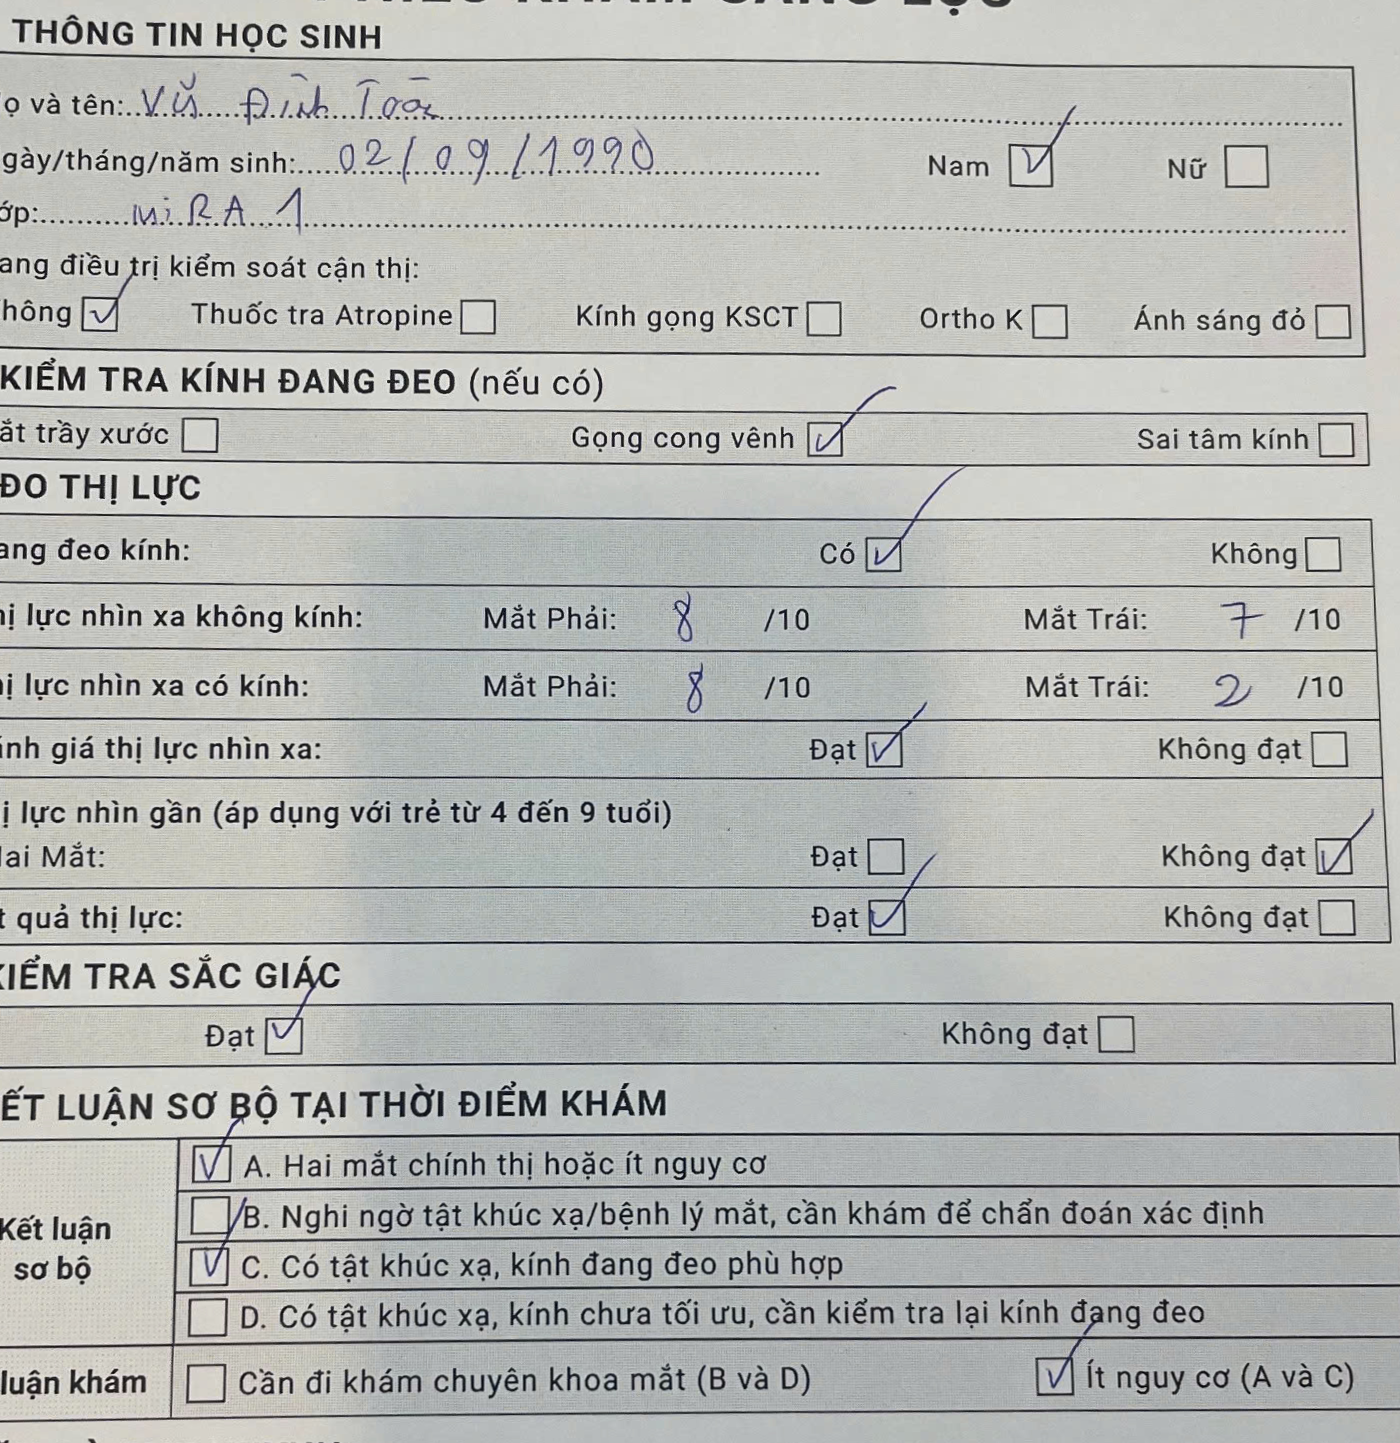

In [17]:
img= cv2.imread("/content/handwriting_aligned.png")
cropped = crop_by_keywords(img, debug=True)

In [18]:
first_info = get_first_info(cropped, debug=True)
print(first_info)

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


{'Họ và tên': 'Vũ Đình Toàn', 'Ngày/tháng/năm sinh': '02/02', 'Lớp': 'M.I.R.A.1'}


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


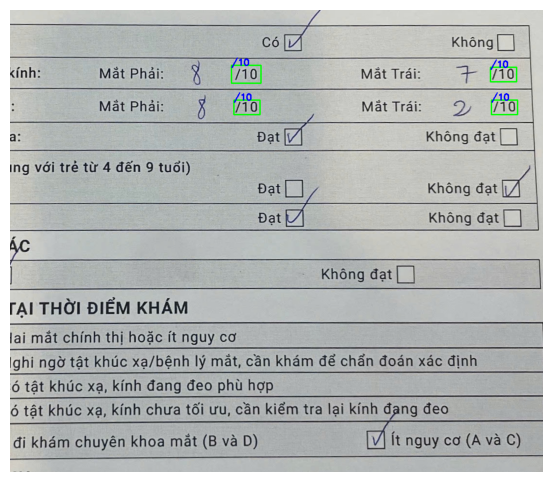

{'Thị lực nhìn xa không kính': {'Mắt Phải': '/10', 'Mắt Trái': '/10'}, 'Thị lực nhìn xa có kính': {'Mắt Phải': '/10', 'Mắt Trái': '/10'}}


In [19]:
second_info = get_second_info(cropped, debug=True)
print(second_info)

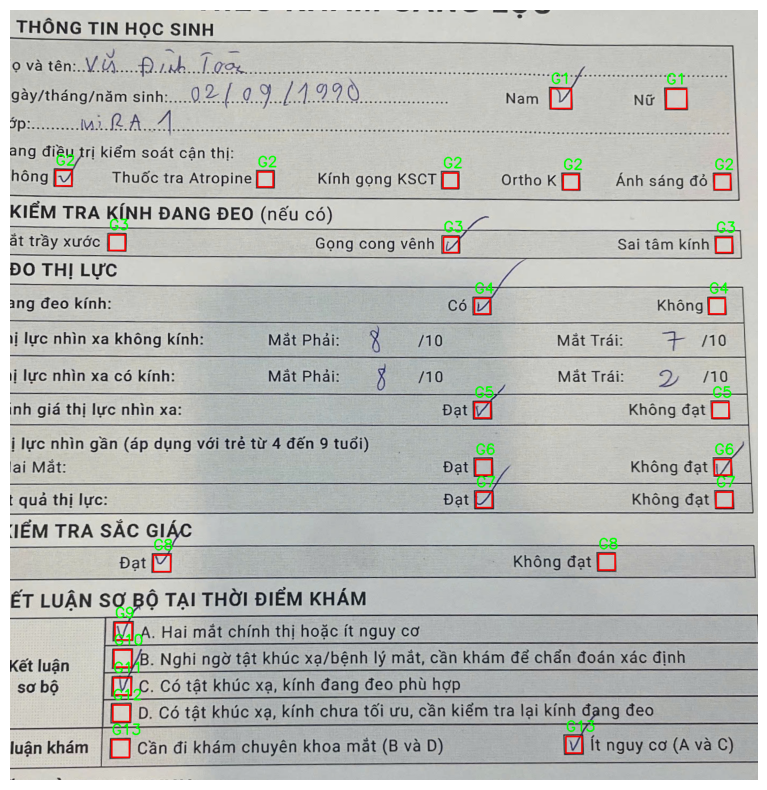

In [20]:
img = cropped.copy()
stats, labels = detect_checkboxes(img)
checkbox_dict = classify_checkboxes(img, stats, n_groups = 13)

plot_checkbox_groups(img.copy(), checkbox_dict)

In [21]:
checkbox_info = summarize_checkbox(checkbox_dict)
print(checkbox_info)

{'Giới tính': 'Nam', 'Đang điều trị kiểm soát cận thị': None, 'KIỂM TRA KÍNH ĐANG ĐEO': 'Gọng cong vênh', 'Đang đeo kính': 'Có', 'Đánh giá thị lực nhìn xa': 'Đạt', 'Thị lực nhìn gần (áp dụng với trẻ từ 4 đến 9 tuổi)': 'Không đạt', 'Kết quả thị lực': 'Đạt', 'Kiểm tra sắc giác': 'Đạt', 'Hai mắt chính thị hoặc ít nguy cơ': 'Hai mắt chính thị hoặc ít nguy cơ', 'Nghi ngờ tật khúc xạ/bệnh lý mắt, cần khám để chẩn đoán xác định': None, 'Có tật khúc xạ, kính đang đeo phù hợp': 'Có tật khúc xạ, kính đang đeo phù hợp', 'Có tật khúc xạ, kính chưa tối ưu, cần kiểm tra lại kính đang đeo': None, 'Kết luận khám': 'Ít nguy cơ (A và C)'}


In [22]:
info = {**first_info, **second_info, **checkbox_info}
info

{'Họ và tên': 'Vũ Đình Toàn',
 'Ngày/tháng/năm sinh': '02/02',
 'Lớp': 'M.I.R.A.1',
 'Thị lực nhìn xa không kính': {'Mắt Phải': '/10', 'Mắt Trái': '/10'},
 'Thị lực nhìn xa có kính': {'Mắt Phải': '/10', 'Mắt Trái': '/10'},
 'Giới tính': 'Nam',
 'Đang điều trị kiểm soát cận thị': None,
 'KIỂM TRA KÍNH ĐANG ĐEO': 'Gọng cong vênh',
 'Đang đeo kính': 'Có',
 'Đánh giá thị lực nhìn xa': 'Đạt',
 'Thị lực nhìn gần (áp dụng với trẻ từ 4 đến 9 tuổi)': 'Không đạt',
 'Kết quả thị lực': 'Đạt',
 'Kiểm tra sắc giác': 'Đạt',
 'Hai mắt chính thị hoặc ít nguy cơ': 'Hai mắt chính thị hoặc ít nguy cơ',
 'Nghi ngờ tật khúc xạ/bệnh lý mắt, cần khám để chẩn đoán xác định': None,
 'Có tật khúc xạ, kính đang đeo phù hợp': 'Có tật khúc xạ, kính đang đeo phù hợp',
 'Có tật khúc xạ, kính chưa tối ưu, cần kiểm tra lại kính đang đeo': None,
 'Kết luận khám': 'Ít nguy cơ (A và C)'}